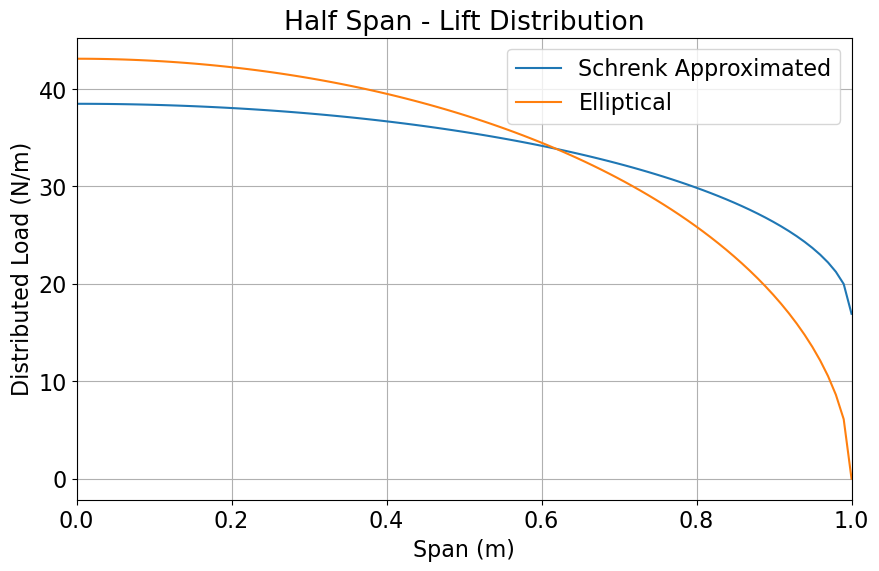

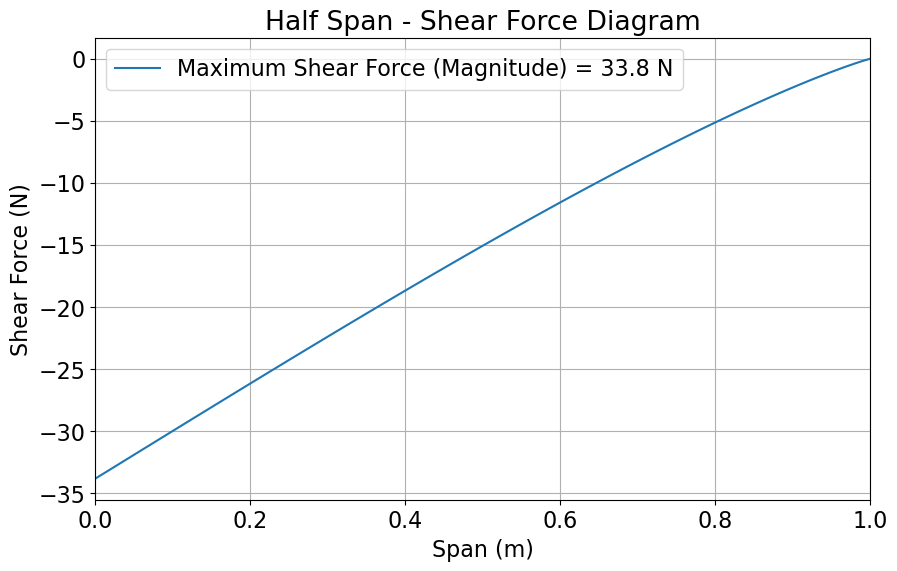

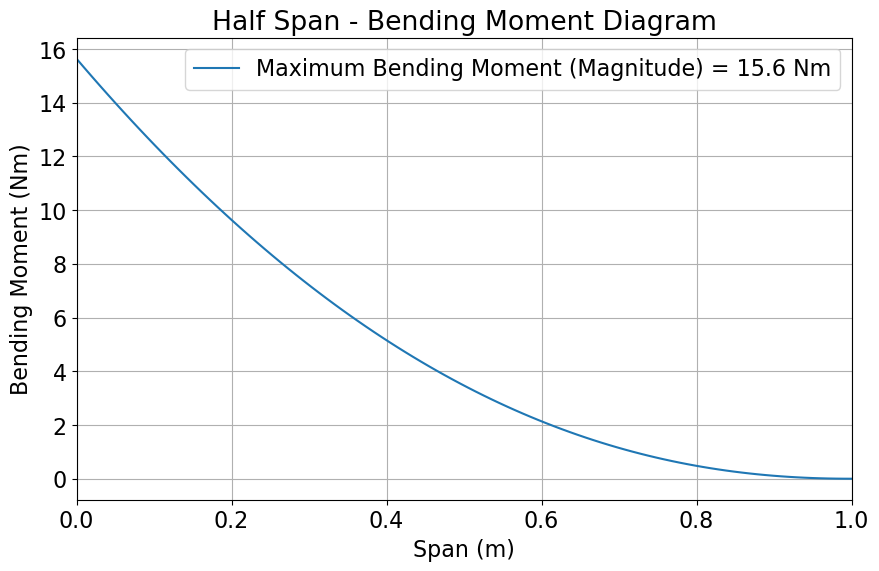

Ixx (skin) = 2.99e-08 m^4


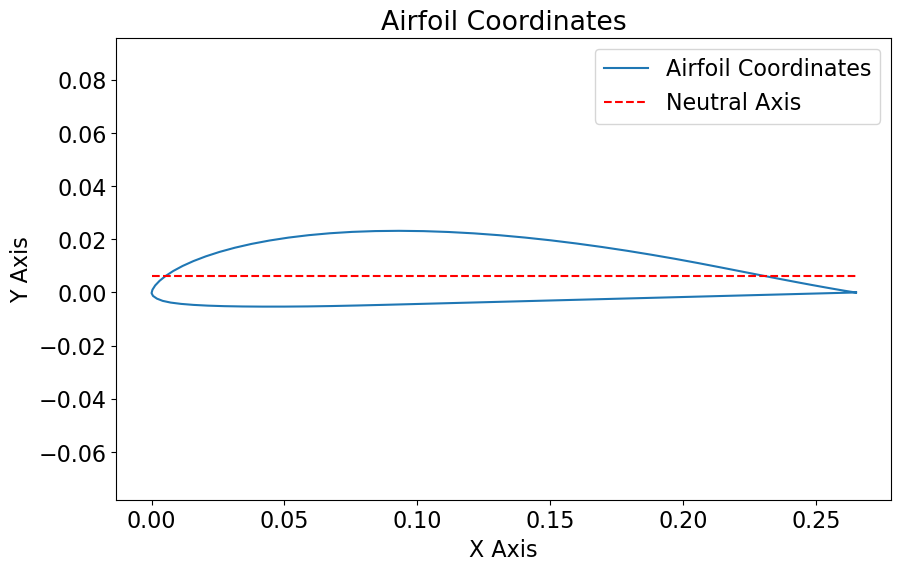

Stress (Design) = 12.7 MPa
Ixx (required, max) = 1.71e-08 m^4


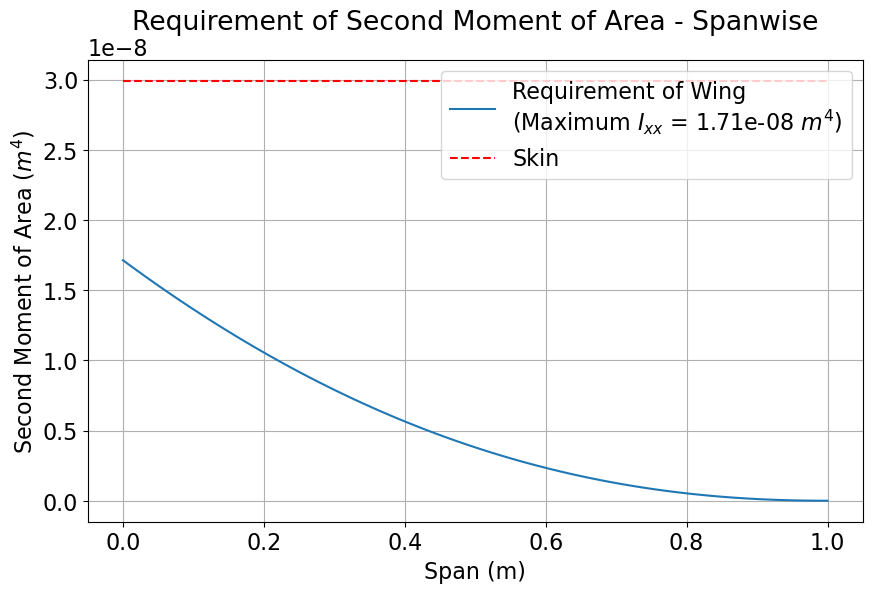

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=16)


# Part 1

# Wing Parameters
b = 2
S = 0.53
W = 6.9*9.81

# Evaluating Chord for Elliptical and Rectangular Wing
x = np.linspace(0, b/2, 100)

c_elliptical = 4*S*np.sqrt(1 - (2*x/b)**2)/(np.pi*b)
c_rectangular = 0.265

# Evaluating Schrenk Equivalent Chord
c_schrenk = (c_rectangular + c_elliptical)/2

# Evaluating Lift Distribution for Schrenk and Elliptical Lift Distribution
k = (W/2)/np.trapz(y=c_schrenk, x=x)

q_schrenk = k*c_schrenk
q_elliptical = k*c_elliptical


# Lift Distribution Plot
plt.figure(figsize=(10, 6))
plt.plot(x, q_schrenk, label="Schrenk Approximated")
plt.plot(x, q_elliptical, label="Elliptical")
plt.title("Half Span - Lift Distribution")
plt.ylabel("Distributed Load (N/m)")
plt.xlabel("Span (m)")
plt.grid()
plt.legend()
plt.xlim(0, 1)
plt.show()


# Calculating Shear Force and Bending Moment 
M = np.zeros_like(q_schrenk)
V = np.zeros_like(q_schrenk)

for i in range(len(M)):
    V[i] = -np.trapz(q_schrenk[i:], x=x[i:])
    M[i] = np.trapz(q_schrenk[i:]*(x[i:] - x[i]), x=x[i:])


# Shear Force Diagram
plt.figure(figsize=(10, 6))
plt.plot(x, V, label=f"Maximum Shear Force (Magnitude) = {max(abs(V)):.3g} N")
plt.title("Half Span - Shear Force Diagram")
plt.xlabel("Span (m)")
plt.ylabel("Shear Force (N)")
plt.xlim(0, 1)
plt.legend()
plt.grid()
plt.show()


# Bending Moment Diagram
plt.figure(figsize=(10, 6))
plt.plot(x, M, label=f"Maximum Bending Moment (Magnitude) = {max(abs(M)):.3g} Nm")
plt.title("Half Span - Bending Moment Diagram")
plt.xlabel("Span (m)")
plt.ylabel("Bending Moment (Nm)")
plt.xlim(0, 1)
plt.legend()
plt.grid()
plt.show()



# Part 2

skin_thickness = 5e-4
chord = 0.265

s7055 = np.loadtxt('s7055.dat')*chord     # Includes Trailing Edge Duplicate

s7055_dl = np.linalg.norm(s7055[:-1, :] - s7055[1:, :], axis=1)
s7055_midpt = (s7055[:-1, :] + s7055[1:, :])/2


# Idealizing skin as Mass Lumps
dA_lump = s7055_dl*skin_thickness
A_skin = np.sum(dA_lump)

y_centroid = np.sum(s7055_midpt[:, 1]*dA_lump)/A_skin
Ixx_skin = np.sum((s7055_midpt[:, 1] - y_centroid)**2*dA_lump)
print(f"Ixx (skin) = {Ixx_skin:.3g} m^4")

# Airfoil Plot (Coordinates, Mid Points & Neutral Axis)
plt.figure(figsize=(10, 6))
plt.plot(s7055[:, 0], s7055[:, 1], label="Airfoil Coordinates")
# plt.scatter(s7055_midpt[:, 0], s7055_midpt[:, 1], s=3, label="Panel Midpoint")
plt.hlines(y=y_centroid, xmin=0, xmax=chord, linestyle="--", color='r', label="Neutral Axis")
plt.title("Airfoil Coordinates")
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.legend()
plt.axis('equal')
plt.show()


# Part 3

# Input Parameters
stress_yield = 150*1e6  # Material: Al1100-H18
n_fos = 1.5
n_vn = 3.5
n_fatigue = 1.5
k_stress_conc_factor = 1.5

airfoil_max_thickness = chord*0.105     # 10.5% Chord
M_root = max(abs(M))
stress_design = stress_yield/(n_fos*n_vn*n_fatigue*k_stress_conc_factor)
print(f"Stress (Design) = {stress_design*1e-6:.3g} MPa")

Ixx_required = (M*airfoil_max_thickness/2)/stress_design
print(f"Ixx (required, max) = {np.max(Ixx_required):.3g} m^4")

# Plots of Second Moment of Area
plt.figure(figsize=(10, 6))
plt.plot(x, Ixx_required, label="Requirement of Wing\n(Maximum $I_{xx}$ = "+f"{np.max(Ixx_required):.3g} $m^4$)")
plt.hlines(y=Ixx_skin, xmin=0, xmax=b/2, linestyle="--", color='r', label="Skin")
plt.title("Requirement of Second Moment of Area - Spanwise")
plt.ylabel("Second Moment of Area $(m^4)$")
plt.xlabel("Span (m)")
plt.grid()
plt.legend()
plt.show()


# plt.figure(figsize=(10, 6))
# plt.plot(x, np.where(Ixx_required - Ixx_skin > 0, Ixx_required - Ixx_skin, 0))
# plt.title("Spar - Second Moment of Area (Requirement)")
# plt.ylabel("Second Moment of Area $(m^4)$")
# plt.xlabel("Span (m)")
# plt.grid()
# plt.show()